In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("case5_image_features_kmeans_1000.csv")
df.head()

,ColorIntensity,TextureScore,ShapeComplexity,EdgeDensity
0,0.680929,0.038433,0.621340,0.844423
1,0.897243,0.275054,0.521489,0.631553
2,0.890827,0.834862,0.861944,0.078709
3,0.976490,0.293890,0.491713,0.486350
4,0.700215,0.056901,0.127743,0.209759


In [4]:
df.columns

Index(['ColorIntensity', 'TextureScore', 'ShapeComplexity', 'EdgeDensity'], dtype='object')

In [5]:
X = df[['ColorIntensity', 'TextureScore', 'ShapeComplexity', 'EdgeDensity']]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

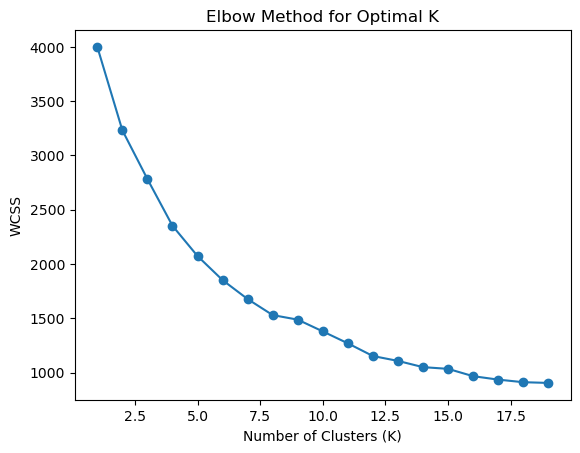

In [19]:
wcss = []

for k in range (1,20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,20), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=7, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

,ColorIntensity,TextureScore,ShapeComplexity,EdgeDensity,Cluster
0,0.680929,0.038433,0.621340,0.844423,6
1,0.897243,0.275054,0.521489,0.631553,6
2,0.890827,0.834862,0.861944,0.078709,4
3,0.976490,0.293890,0.491713,0.486350,2
4,0.700215,0.056901,0.127743,0.209759,2
...,...,...,...,...,...
995,0.256044,0.933818,0.219759,0.266460,3
996,0.119893,0.893952,0.650101,0.404192,4
997,0.911515,0.776282,0.904354,0.701856,5
998,0.997962,0.718273,0.085489,0.038805,3


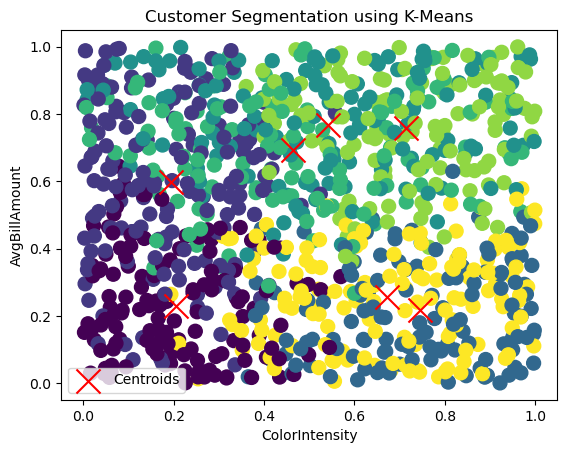

In [22]:
#Visualize the cluster
plt.figure()

plt.scatter(
    df['ColorIntensity'], df['TextureScore'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("ColorIntensity")
plt.ylabel("AvgBillAmount")
plt.title("Customer Segmentation using K-Means")

#Now plotting centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0], centroids[:,1], s=300, c='red', marker='x', label='Centroids')
plt.legend()
plt.show()